In [1]:
!pip install -r requirements.txt -qqq

In [2]:
import numpy as np
import pandas as pd
import os

import matplotlib.pyplot as plt
%matplotlib inline
from tqdm import tqdm_notebook
from sklearn.preprocessing import StandardScaler
from sklearn.svm import NuSVR, SVR
from sklearn.metrics import mean_absolute_error
pd.options.display.precision = 15

import lightgbm as lgb
import xgboost as xgb
import time
import datetime
from catboost import CatBoostRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, KFold, RepeatedKFold, GroupKFold, GridSearchCV, train_test_split, TimeSeriesSplit
from sklearn import metrics
from sklearn import linear_model
import gc
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

import eli5
import shap
from IPython.display import HTML
import json
import altair as alt

import networkx as nx
import matplotlib.pyplot as plt
%matplotlib inline

alt.renderers.enable('mimetype')

%env JOBLIB_TEMP_FOLDER=/tmp

env: JOBLIB_TEMP_FOLDER=/tmp


In [3]:
folder_path = 'dataset/'
train_identity = pd.read_csv(f'{folder_path}train_identity.csv')
train_transaction = pd.read_csv(f'{folder_path}train_transaction.csv')
test_identity = pd.read_csv(f'{folder_path}test_identity.csv')
test_transaction = pd.read_csv(f'{folder_path}test_transaction.csv')

# let's combine the data and work with the whole dataset
train = pd.merge(train_transaction, train_identity, on='TransactionID', how='left')
test = pd.merge(test_transaction, test_identity, on='TransactionID', how='left')

RANDOM_SEED = 42

In [4]:
del train_identity, train_transaction, test_identity, test_transaction

In [5]:
print(train.columns.tolist())

['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74', 'V75', 'V76', 'V77', 'V78', 'V79', 'V80', 'V81', 'V

In [6]:
train['isFraud'].value_counts(normalize=True)

isFraud
0    0.965009990855827
1    0.034990009144173
Name: proportion, dtype: float64

In [7]:
# columns grouping
# transaction columns
transaction_cols = ["TransactionID", "TransactionDT", "TransactionAmt"]
# product columns
product_cols = ["ProductCD"]
# card columns
card_cols = ["card1", "card2", "card3", "card4", "card5", "card6"]
# address columns
address_cols = ["addr1", "addr2"]
# email columns
email_cols = ["P_emaildomain", "R_emaildomain"]
# distance columns
distance_cols = ["dist1", "dist2"]
# matching features columns
matching_cols = ["M1", "M2", "M3", "M4", "M5", "M6", "M7", "M8", "M9"]
# count columns
count_cols = [f"C{i}" for i in range(1, 15)]
# delay columns
delay_cols = [f"D{i}" for i in range(1, 16)]
# v columns
v_cols = [f"V{i}" for i in range(1, 340)]
# device columns
device_cols = ["DeviceType", "DeviceInfo"]
# identity columns
identity_cols = [f"id_{str(i).zfill(2)}" for i in range(1, 39)]
# device metadata columns 
# id_30: Operating System, 
# id_31: Browser
# id_32: screen color depth
# id_33: screen resolution
device_metadata_cols = ["DeviceType", "DeviceInfo", "id_30", "id_31", "id_32", "id_33"]

In [8]:
check = train[["TransactionID", "TransactionDT", "TransactionAmt", "DeviceType", "DeviceInfo", "id_30", "id_31", "id_32", "id_33", "isFraud"]]
check[check["isFraud"] == True]

,TransactionID,TransactionDT,TransactionAmt,DeviceType,DeviceInfo,id_30,id_31,id_32,id_33,isFraud
203,2987203,89760,445.000000000000000,NaN,NaN,NaN,NaN,NaN,NaN,1
240,2987240,90193,37.097999999999999,mobile,Redmi Note 4 Build/MMB29M,NaN,chrome 54.0 for android,NaN,NaN,1
243,2987243,90246,37.097999999999999,mobile,Redmi Note 4 Build/MMB29M,NaN,chrome 54.0 for android,NaN,NaN,1
245,2987245,90295,37.097999999999999,mobile,Redmi Note 4 Build/MMB29M,NaN,chrome 54.0 for android,NaN,NaN,1
288,2987288,90986,155.520999999999987,mobile,NaN,NaN,chrome 62.0 for ios,NaN,NaN,1
...,...,...,...,...,...,...,...,...,...,...
590361,3577361,15807368,1224.000000000000000,NaN,NaN,NaN,NaN,NaN,NaN,1
590364,3577364,15807516,69.963999999999999,mobile,SAMSUNG SM-J700M Build/MMB29K,NaN,samsung browser 6.4,NaN,NaN,1
590368,3577368,15807677,100.000000000000000,mobile,iOS Device,iOS 11.3.0,mobile safari 11.0,32.0,2208x1242,1
590372,3577372,15807758,117.000000000000000,NaN,NaN,NaN,NaN,NaN,NaN,1


In [9]:
pd.crosstab(
    train['id_28'],
    train['isFraud'],
    normalize='index'
)

isFraud,0,1
id_28,,
Found,0.897247874908175,0.102752125091825
New,0.947718777994007,0.052281222005993


<Axes: xlabel='isFraud', ylabel='id_01'>

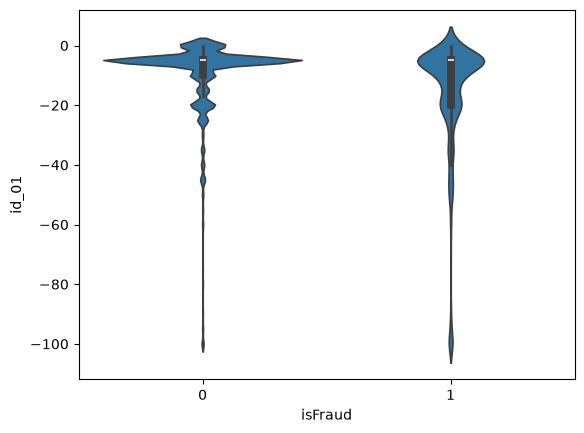

In [16]:
col = "id_01"
sns.violinplot(train, x='isFraud', y=col)

In [17]:
train[col].value_counts(dropna=False).head()

id_01
 NaN     446307
-5.0      82170
 0.0      19555
-10.0     11257
-20.0     11211
Name: count, dtype: int64

In [18]:
train[col].value_counts(dropna=False, normalize=True).head()

id_01
 NaN     0.755760829071697
-5.0     0.139143834456599
 0.0     0.033113760287195
-10.0    0.019062214244590
-20.0    0.018984319436448
Name: proportion, dtype: float64

In [19]:
# charts = {}
# for i in ["id_12", "id_15", "id_16", "id_28", "id_29", "id_30", "id_31", "id_32", "id_33", "id_34", "id_35", "id_36", "id_37", "id_38"]:
#     feature_count = train[i].value_counts(dropna=False).rename_axis(i).reset_index(name="count")
#     chart = alt.Chart(feature_count).mark_bar().encode(
#         y=alt.Y(f"{i}:N", axis=alt.Axis(title=i)),
#         x=alt.X("count:Q", axis=alt.Axis(title="Count")),
#         tooltip=[i, "count"],
#     ).properties(title=f"Counts of {i}", width=400)
#     charts[i] = chart

# render((charts["id_12"] | charts["id_15"] | charts["id_16"]) & (charts["id_28"] | charts["id_29"] | charts["id_32"]) & (charts["id_34"] | charts["id_35"] | charts["id_36"]) & (charts["id_37"] | charts["id_38"]))